# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [2]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [96]:
from sklearn.model_selection import train_test_split

df_clear = df.drop(columns = ['salary']) # это тоже самое, только в валюте страны
train_val, test = train_test_split(df_clear, train_size=0.9, random_state=1309)
train, val = train_test_split(train_val, train_size=8/9, random_state=1309)

X_train_d =  train.drop(columns = ['salary_in_usd'])
y_train = train['salary_in_usd']

X_val_d =  val.drop(columns = ['salary_in_usd'])
y_val = val['salary_in_usd']

X_test_d =  test.drop(columns = ['salary_in_usd'])
y_test = test['salary_in_usd']

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features =['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoder.fit(X_train_d[categorical_features])
X_train = pd.concat([X_train_d.drop(columns = categorical_features), pd.DataFrame(encoder.transform(X_train_d[categorical_features]), index=X_train_d.index)], axis=1)
X_test = pd.concat([X_test_d.drop(columns = categorical_features), pd.DataFrame(encoder.transform(X_test_d[categorical_features]), index=X_test_d.index)], axis=1)
X_val = pd.concat([X_val_d.drop(columns = categorical_features), pd.DataFrame(encoder.transform(X_val_d[categorical_features]), index=X_val_d.index)], axis=1)

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
X_val.columns = X_val.columns.astype(str)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [98]:
%%time
lr = LinearRegression()
lr.fit(X_train, y_train)

CPU times: user 129 ms, sys: 3.93 ms, total: 133 ms
Wall time: 80 ms


LinearRegression()

In [99]:
y_val_pred = lr.predict(X_val)

print('MAPE: ',  mean_absolute_percentage_error(y_val, y_val_pred))
print('RMSE: ', root_mean_squared_error(y_val, y_val_pred) )

MAPE:  0.42231812949705955
RMSE:  48136.36583167074


In [100]:
%%time
y_test_pred = lr.predict(X_test)

CPU times: user 4.3 ms, sys: 8 µs, total: 4.31 ms
Wall time: 3.91 ms


In [101]:
print('MAPE: ',  mean_absolute_percentage_error(y_test, y_test_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_test_pred) )

MAPE:  0.39075780628553863
RMSE:  48406.202692731255


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [102]:
from xgboost.sklearn import XGBRegressor

RMSE = []
for max_depth in range(1, 11):
  m_t = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=max_depth, early_stopping_rounds=50, eval_metric='rmse', random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

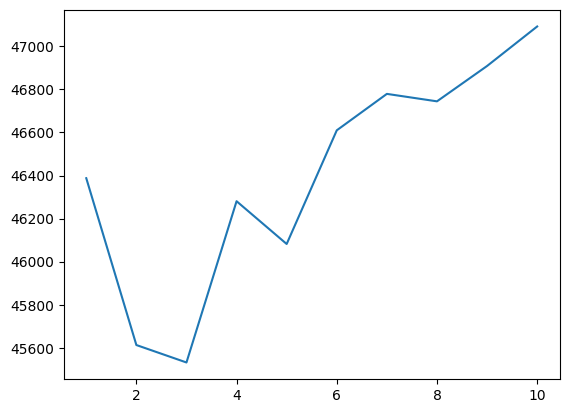

In [103]:
import seaborn as sns

sns.lineplot(x = range(1, 11), y = RMSE)

Лучшие резы на глубине 3. Количество моделей мы отдали на откуп ранней остановке. Теперь гаммы посмотрим

In [104]:
from xgboost.sklearn import XGBRegressor

gammas = [0, 0.5, 1, 2, 5]
RMSE = []
for g in gammas:
  m_t = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=3, early_stopping_rounds=50, eval_metric='rmse', gamma = g, random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

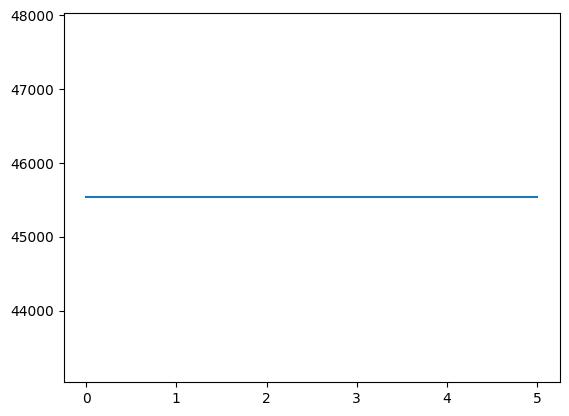

In [105]:
sns.lineplot(x = gammas, y = RMSE)

In [106]:
lrs = [0.01, 0.05, 0.1, 0.5, 1]

RMSE = []
for lr in lrs:
  m_t = XGBRegressor(n_estimators=1000, learning_rate=lr, max_depth=3, early_stopping_rounds=50, eval_metric='rmse', random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

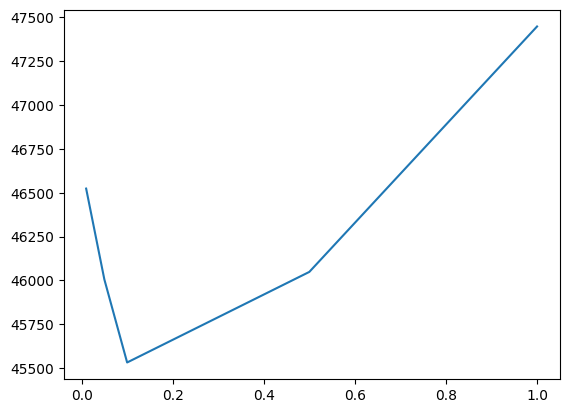

In [107]:
sns.lineplot(x = lrs, y = RMSE)

Оставляем 0.1

In [108]:
print(RMSE)

[46523.890625, 46005.57421875, 45531.90234375, 46048.5546875, 47448.66015625]


Ну это что-то прям вообще не роляет

In [109]:
%%time
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=3, early_stopping_rounds=50, eval_metric='rmse', random_state = 1309)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

CPU times: user 4.05 s, sys: 23.1 ms, total: 4.07 s
Wall time: 2.1 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [110]:
%%time
y_test_pred = xgb.predict(X_test)

CPU times: user 29.9 ms, sys: 966 µs, total: 30.8 ms
Wall time: 24.1 ms


In [111]:


print('MAPE: ',  mean_absolute_percentage_error(y_test, y_test_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_test_pred) )

MAPE:  0.40516361594200134
RMSE:  46142.53515625


Обучение - в 25 раз дольше, а предсказание в 6. MAPE немного подросла, а RMSE чуток упала

## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [45]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [112]:
from catboost import CatBoostRegressor

RMSE = []
for max_depth in range(1, 11):
  m_t = CatBoostRegressor(n_estimators=1000, learning_rate=0.1, max_depth=max_depth, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

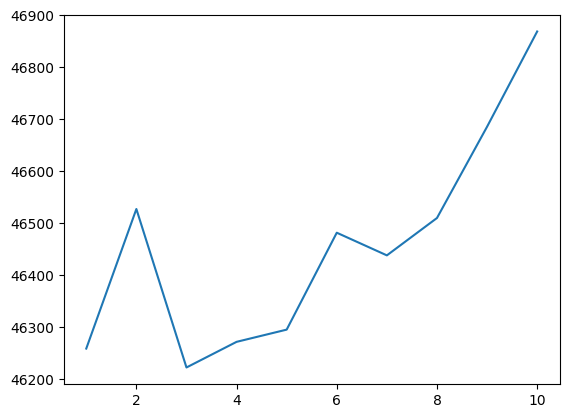

In [113]:
sns.lineplot(x = range(1, 11), y = RMSE)

Лучшая глубина 3. Количество итераций на early stopping.

In [114]:
from catboost import CatBoostRegressor

lrs = [0.01, 0.05, 0.1, 0.5, 1]

RMSE = []
for lr in lrs:
  m_t = CatBoostRegressor(n_estimators=1000, learning_rate=lr, max_depth=3, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

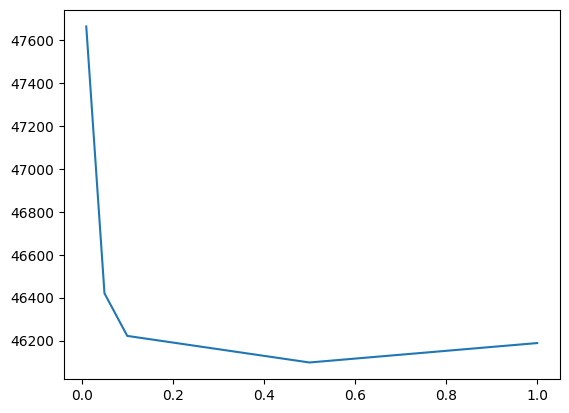

In [115]:
sns.lineplot(x = lrs, y = RMSE)

Берём 0.5

In [164]:
%%time
CAT =  CatBoostRegressor(n_estimators=1000, learning_rate=0.5, max_depth=3, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309)
CAT.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

CPU times: user 377 ms, sys: 31.7 ms, total: 409 ms
Wall time: 416 ms


CatBoostRegressor(early_stopping_rounds=50, eval_metric='RMSE', learning_rate=0.5, loss_function='RMSE', max_depth=3, n_estimators=1000, random_state=1309)

In [166]:
%%time
y_test_pred = CAT.predict(X_test)

CPU times: user 6.2 ms, sys: 973 µs, total: 7.18 ms
Wall time: 5.47 ms


In [118]:
print('MAPE: ',  mean_absolute_percentage_error(y_test, y_test_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_test_pred) )

MAPE:  0.4239827006369972
RMSE:  47525.48092862425


Скорость обучения в 8 раз лучше, чем у xgb, а предсказания - в 4 раза. По MAE - наихудший результат. По RMSE - лучше линейной, но хуже xgb

Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [119]:
from catboost import Pool

train_pool = Pool(X_train_d, y_train, cat_features=categorical_features)
val_pool   = Pool(X_val_d,   y_val,   cat_features=categorical_features)
test_pool  = Pool(X_test_d,  y_test,  cat_features=categorical_features)

In [120]:
RMSE = []
for max_depth in range(1, 11):
    m_t = CatBoostRegressor(n_estimators=1000, learning_rate=0.1, max_depth=max_depth,
                            early_stopping_rounds=50, eval_metric='RMSE', random_state=1309)
    m_t.fit(train_pool, eval_set=val_pool, verbose=False)
    y_val_pred = m_t.predict(val_pool)
    RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

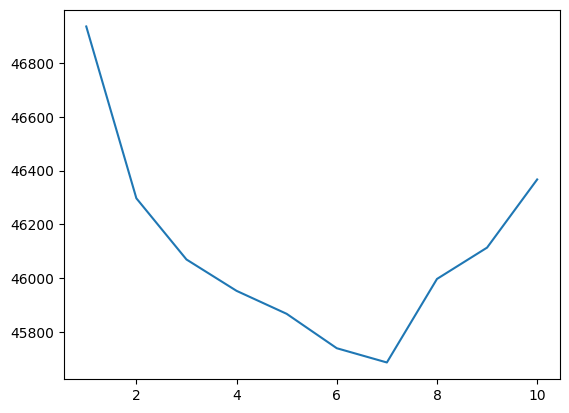

In [121]:
sns.lineplot(x = range(1, 11), y = RMSE)

Берём 7

In [122]:
lrs = [0.01, 0.05, 0.1, 0.5, 1]

RMSE = []
for lr in lrs:
  m_t = CatBoostRegressor(n_estimators=1000, learning_rate=lr, max_depth=7, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309)
  m_t.fit(train_pool, eval_set=val_pool, verbose=False)
  y_val_pred = m_t.predict(val_pool)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

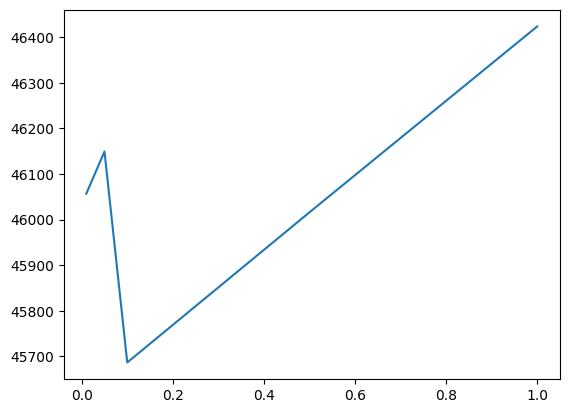

In [123]:
sns.lineplot(x = lrs, y = RMSE)

lr = 0.1

In [124]:
%%time
CAT = CatBoostRegressor(n_estimators=1000, learning_rate=0.1, max_depth=7, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309)
CAT.fit(train_pool, eval_set=val_pool, verbose=False)

CPU times: user 4.43 s, sys: 369 ms, total: 4.8 s
Wall time: 2.53 s


CatBoostRegressor(early_stopping_rounds=50, eval_metric='RMSE', learning_rate=0.1, loss_function='RMSE', max_depth=7, n_estimators=1000, random_state=1309)

In [125]:
%%time
y_test_pred = CAT.predict(test_pool)

CPU times: user 2.45 ms, sys: 17 µs, total: 2.46 ms
Wall time: 1.86 ms


In [126]:
print('MAPE: ',  mean_absolute_percentage_error(y_test, y_test_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_test_pred) )

MAPE:  0.4449711095196073
RMSE:  46723.5014777776


**Ответ:** стало лучше по RMSE, а MAPE опять ухудшилось. Обучение стало дольше раз в 8, а скорость предсказания -  в 4 раза меньше.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [152]:
from lightgbm import LGBMRegressor


RMSE = []
for max_depth in range(1, 11):
  m_t = LGBMRegressor(n_estimators=1000, learning_rate=0.1, max_depth=max_depth, early_stopping_rounds=50, eval_metric='RMSE', verbose = -1, random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)])
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

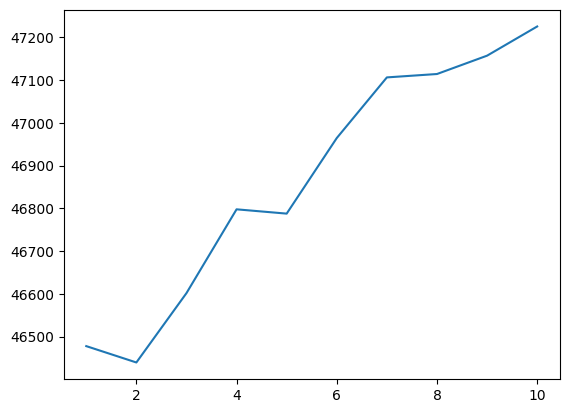

In [153]:
sns.lineplot(x = range(1, 11), y = RMSE)

глубина 2

In [154]:
lrs = [0.01, 0.05, 0.1, 0.5, 1]

RMSE = []
for lr in lrs:
  m_t = LGBMRegressor(n_estimators=1000, learning_rate=lr, max_depth=2, early_stopping_rounds=50, verbose = -1, random_state = 1309)
  m_t.fit(X_train, y_train, eval_set=[(X_val, y_val)])
  y_val_pred = m_t.predict(X_val)
  RMSE.append(root_mean_squared_error(y_val, y_val_pred))

<Axes: >

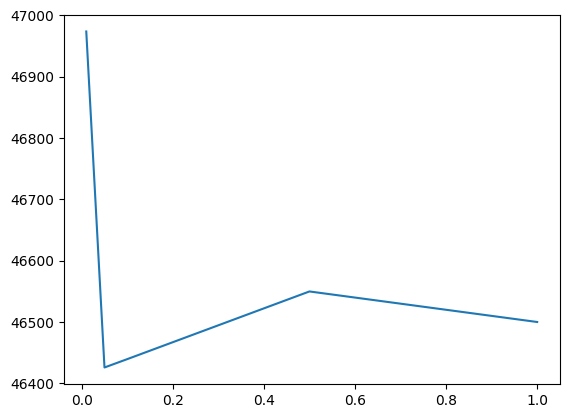

In [155]:
sns.lineplot(x = lrs, y = RMSE)

lr - 0.1

In [160]:
%%time
LGBM = LGBMRegressor(n_estimators=1000, learning_rate=0.1, max_depth=2, early_stopping_rounds=50, eval_metric='RMSE', random_state = 1309, verbose = -1)
LGBM.fit(X_train, y_train, eval_set=[(X_val, y_val)])

CPU times: user 126 ms, sys: 4.94 ms, total: 131 ms
Wall time: 134 ms


LGBMRegressor(early_stopping_rounds=50, eval_metric='RMSE', max_depth=2,
              n_estimators=1000, random_state=1309, verbose=-1)

In [161]:
%%time
y_test_pred = LGBM.predict(X_test)

CPU times: user 5.75 ms, sys: 1.05 ms, total: 6.81 ms
Wall time: 8.41 ms


In [162]:
print('MAPE: ',  mean_absolute_percentage_error(y_test, y_test_pred))
print('RMSE: ', root_mean_squared_error(y_test, y_test_pred) )

MAPE:  0.4190138226455633
RMSE:  47873.33878714827


Это худший RMSE из всех бустингов, но MAPE - посерединке. Скорость обучения самая высокая, а скорость предсказания в пределах погрешности

## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** Лучше всех бустингов является XGB, а худшим - LGBM, в основном я смотрел на RMSE, так как оптимизировали именно её, а MAPE скорее второстепенна и не настолько показательна, так как работает с процентами от зарплаты, что мне кажется не настолько важно. А по скорости обучения всех превзошёл LGBM, а по предсказанию - Catboost без изначального преобразования категориальных признаков. Дольше всего предсказывает XGB.

По параметрам - скорость обучения почти у всех равна 0.1, кроме Catboost, у которого 0.5. А глубина уже чуть более разнообразна - есть две (XGB, наш catboost), у которых глубина - 3, у LGBM - 2, и у Catboost без изначального преобразования категориальных признаков равна 7

Ещё стоит отметить 2 вещи: \
Во-первых, встроенное преобразование CatBoost даёт лучше результат, чем OneHot. \
Во-вторых, все результаты очень близки и не так уж и далеко от линейной модели

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [167]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [168]:
ratings_t = ratings.T

Выкиньте строку под названием `user`.

In [169]:
ratings_t = ratings_t.drop('user')

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [170]:
ratings_t = ratings_t.fillna(0)
ratings_t.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
rob zombie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [195]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, n_init='auto', random_state=1309)
cluster_labels = kmeans.fit_predict(ratings_t)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [196]:
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_sizes)

0      1
1     74
2      1
3      1
4    923
Name: count, dtype: int64


**Ответ:** Ну что-то прям очень плохо. 3 кластера прям совсем не нужны. Kmeans обязан сделать столько классов, сколько мы ему дали, поэтому вот пришлось добавить классы из одной точки. Да и в целом не кайф, что почти всё ушло в один кластер

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [197]:
single_clusters = cluster_sizes[cluster_sizes == 1].index
artists = ratings_t.index[pd.Series(cluster_labels).isin(single_clusters)]
print(artists)

Index(['the beatles', 'the mars volta', 'the eagles'], dtype='object')


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [198]:
print(ratings_t.loc['the beatles'])

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.043529
          ...   
4995    0.017884
4996    0.000000
4997    0.076923
4998    0.000000
4999    0.000000
Name: the beatles, Length: 5000, dtype: float64


In [199]:
print(ratings_t.mean(axis=1))

the beatles           0.018369
radiohead             0.011851
deathcab for cutie    0.006543
coldplay              0.006030
modest mouse          0.005876
                        ...   
michal w. smith       0.000895
群星                    0.000519
agalloch              0.000997
meshuggah             0.000431
yellowcard            0.000320
Length: 1000, dtype: float64


In [200]:
(ratings_t > 0).sum(axis=1)

,0
the beatles,1671
radiohead,1389
deathcab for cutie,931
coldplay,841
modest mouse,814
...,...
michal w. smith,47
群星,47
agalloch,47
meshuggah,47


In [201]:
(ratings_t**2).sum(axis=1)

,0
the beatles,13.040351
radiohead,4.770043
deathcab for cutie,2.020758
coldplay,2.254842
modest mouse,2.412204
...,...
michal w. smith,0.979948
群星,0.376416
agalloch,1.269898
meshuggah,0.261310


**Ответ:** Очень много людей слушаю битлз, из-за этого радиус вектор огромный и он выродился в отдельный кластер

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [202]:
from sklearn.preprocessing import normalize

ratings_norm = normalize(ratings_t)

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [203]:
km = KMeans(n_clusters=5, random_state=1309)
labels_norm = km.fit_predict(ratings_norm)

In [204]:
cluster_sizes = pd.Series(labels_norm).value_counts().sort_index()
print(cluster_sizes)

0     94
1    284
2    239
3    272
4    111
Name: count, dtype: int64


**Ответ** Кластеры стали более-менее нормально распределены, и теоретически это может быть полезно

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [205]:
from scipy.spatial.distance import cosine


centroids = km.cluster_centers_

artists = ratings_t.index

for i, c in enumerate(centroids):
    dists = [cosine(c, ratings_norm[j]) for j in range(len(ratings_norm))]
    top10 = pd.Series(dists, index=artists).nsmallest(10)
    print(i)
    print(list(top10.index))

0
['the rolling stones', 'the beatles', 'led zeppelin.', 'who', 'dylan. bob', 'foreigner-', 'eric clapton', 'pink fluid', 'simon and garfunkel', 'acdc']
1
['system of a down', 'metallica', 'tool', 'koЯn', 'foo fighters', '\u200clinkin park', 'niИ', 'ratm', 'red hot clili peppers', 'incubus']
2
['kanye west', 'nas', 'jay-z', "the roots featuring d'angelo", 'lupe the gorilla', 'a tribe called quest', 'mos def', 'alicia keys', "lil' wayne", 'little brother']
3
['radiohead', 'the arcade fire', 'animal collective', 'broken social scene', 'belle and sebastian', 'sufjan stevens', 'the pixies', 'of montreal', 'the shins', 'sonic youth']
4
['fall out boy', 'paramore', 'cartel', 'dashboard confesssional', 'anberlin', 'taking back sunday', 'brand new', 'saosin', 'all time low', 'mayday parade']


**Ответ:** # Я плохо разбираюсь в зарубежной музыке, но точно могу сказать, что:
\
0 класс отвечает за классический рок прошлого века \
1 класс отвечает за рокешник 90-ч \
2 класс вроде бы рэп хип хоп \


---
А дальше я вообще ничего не знаю, поэтому надо гуглить:
Мне гугл сказал, что 3 класс - это инди рок, а 4 класс - это эмо и панки. \
Разделение получилось невероятно осмысленным, прям по стиляи поделилось



## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

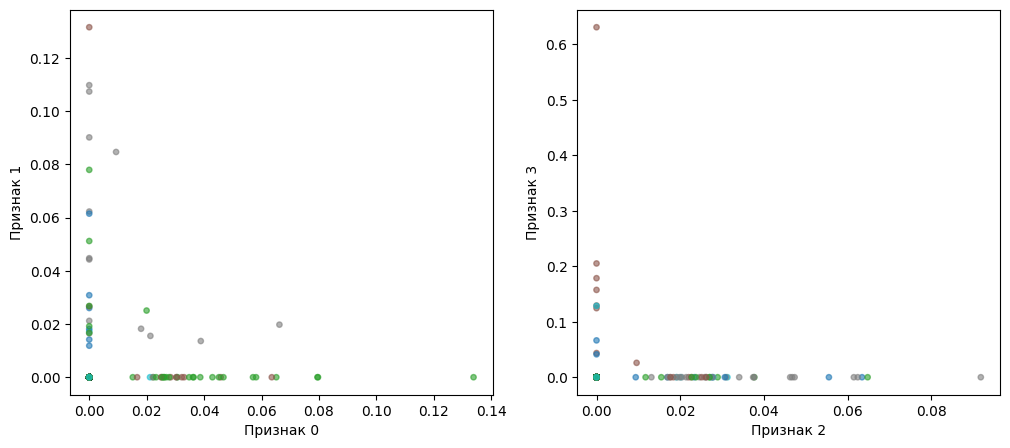

In [207]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(ratings_norm[:, 0], ratings_norm[:, 1], c=labels_norm, cmap='tab10', alpha=0.6, s=15)
plt.xlabel('Признак 0')
plt.ylabel('Признак 1')


plt.subplot(1, 2, 2)
plt.scatter(ratings_norm[:, 2], ratings_norm[:, 3], c=labels_norm, cmap='tab10', alpha=0.6, s=15)
plt.xlabel('Признак 2')
plt.ylabel('Признак 3')

plt.show()

**Ответ:** Вообще неинформативно. Это получилось так как все признаки только суммарно дают разделение. А по отдельности они очень слабенько влияют, это всего 2 из 5000

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


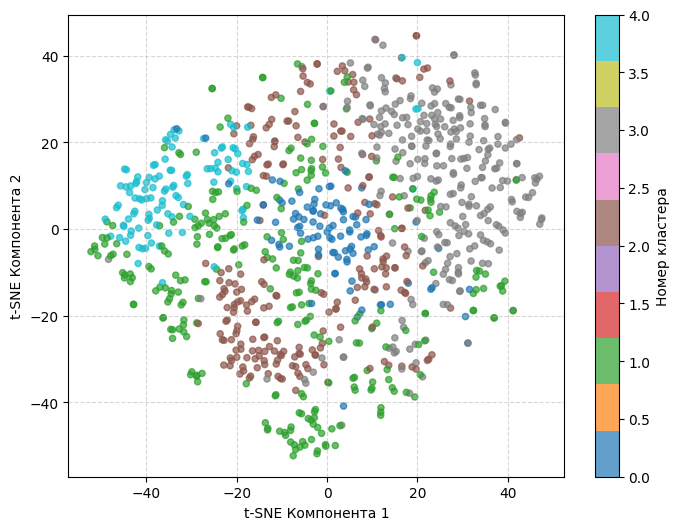

In [209]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=1309, n_iter=1000)
sokr = tsne.fit_transform(ratings_norm)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(sokr[:, 0], sokr[:, 1], c=labels_norm, cmap='tab10', alpha=0.7, s=20)

plt.xlabel('t-SNE Компонента 1')
plt.ylabel('t-SNE Компонента 2')
plt.colorbar(scatter, label='Номер кластера')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [212]:
from sklearn.metrics import silhouette_score


scores = []
k_range = range(2, 101)

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(ratings_norm)
    score = silhouette_score(ratings_norm, labels)
    scores.append(score)



NameError: name 'np' is not defined

In [213]:
import numpy as np
optimal_k = k_range[np.argmax(scores)]
print(f"{optimal_k}")
print(f"{max(scores):.4f}")

98
0.0133


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [214]:
from sklearn.metrics.pairwise import cosine_similarity

best_km = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
best_labels = best_km.fit_predict(ratings_norm)
best_centroids = best_km.cluster_centers_

sim_matrix = cosine_similarity(ratings_norm, best_centroids)

for cluster_idx in range(optimal_k):
    scores = sim_matrix[:, cluster_idx]
    top_10_idx = np.argsort(scores)[::-1][:10]
    top_10_artists = ratings_t.index[top_10_idx]

    print(f"{cluster_idx}")
    print(", ".join(top_10_artists))


0
dr. dre, the faint, violent femmes, margot and the nuclear so and sos, owen, the bloodhound gang, cursive, van hallen, bright eyes, ironand wine
1
john mayer, matt nathanson, gavin degraw, jason mraz, ray lamontagne, joshua radin, sara bareilles, augustana, maroon5, o.a.r.
2
white stripes, beck, the raconteurs, spoon, the pixies, the strokes, the flaming lips, cake, black rebel motorcycle club, gorillaz
3
fugazi, jawbreaker, sleater-kinney, les savy fav, capn jazz, bad brains, blonde redhead, propagandhi, the melvins, gogol bordello
4
ryan adams, band of horses, ryan adams and the cardinals, rogue wave, my morning jacket, matt pond pa, cloud cult, the american analog set, nada surf, tv on the radio
5
dj shadow, rjd2, amon tobin, jedi mind tricks, el-p, aphex twin, sublime, moby*, gnarls barkley, soul coughing
6
system of a down, koЯn, mudvayne, limpt bizkit, disturbed, slipknot, papa roach, godsmack, marilyn manson, fort minor
7
somethings corporate, the rocket summer, jack’s mannequ

**Ответ:** Ухты как здорово вышло. Тут уже узкие жанры \
38. lady gaga, brritney spears, tatu, pink*, madonna, veronicas, timbaland, tori amos, kylie minogue, shakira \
Женская поп музыка, почти всех знаю. Особенно тату порадовали) \
73. Бах Иоганн Себастьян, ВИВАЛЬДИ, Вольфганг Амадей Моцарт, ШОПЕН, ルートヴィヒ・ヴァン・ベートーヴェン, Йrik satie, john williams (g), miles davis., the original cast, john coltrane \
Вот это тоже замечательно, на русском выписаны классические композиторы - это прям вау, я даже погуглил - ルートヴィヒ・ヴァン・ベートーヴェン - это бетховен на японском)))



Сделайте t-SNE визуализацию полученной кластеризации.

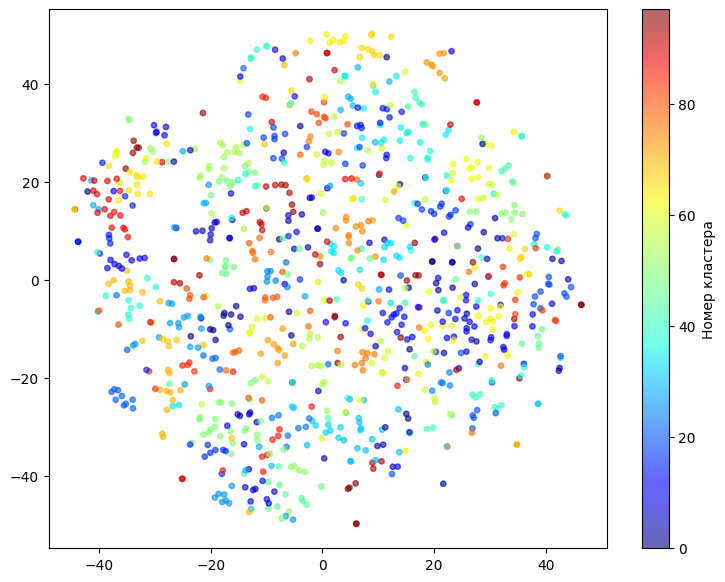

In [216]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
plt.figure(figsize=(9, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=best_labels, cmap='jet', alpha=0.6, s=15)
plt.colorbar(scatter, label='Номер кластера')
plt.show()


Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

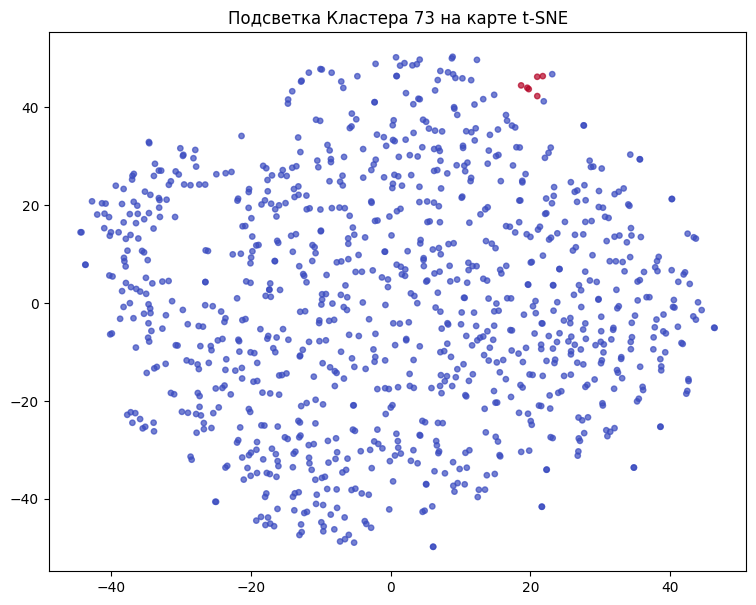

In [218]:
target_cluster_idx = 73
highlight_labels = (best_labels == target_cluster_idx)

plt.figure(figsize=(9, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=highlight_labels, cmap='coolwarm', alpha=0.7, s=15)
plt.title(f'Подсветка Кластера {target_cluster_idx} на карте t-SNE')
plt.show()


**Ответ:** Да, вполне обособленно сидят